# Notebook 06 — Validación out-of-sample del modelo BiLSTM

**Objetivo:** validar las predicciones del modelo BiLSTM (período 18-nov al 17-dic 2025) contra la **demanda real** registrada en ese mismo período, usando un reporte de ventas independiente (`AÑO_2025_VENTAS.xls`).

**Flujo:**
1. Carga y limpieza del reporte crudo (2 hojas de Crystal Reports)
2. Verificación de consistencia con `dataset_crudo.csv` (período común)
3. EDA enfocado al período de validación (¿hubo pico estacional de fin de año?)
4. Validación: predicho vs real (errores por producto)
5. Exportación de resultados

> **Nota metodológica:** el modelo se entrenó con datos hasta el 17-nov-2025. El período 18-nov a 17-dic-2025 es genuinamente *out-of-sample* (el modelo nunca lo vio), por lo que constituye una validación real de la capacidad predictiva.

In [5]:
# Dependencia para leer archivos .xls (Crystal Reports)
import sys, subprocess
subprocess.run([sys.executable, "-m", "pip", "install", "xlrd>=2.0.1", "-q"])

CompletedProcess(args=['c:\\Users\\javic\\Desktop\\PUCESA\\.Archivos\\Test_Semana_9\\eda+modelo\\Tesis_Combustible\\Red Nuronal\\venv\\Scripts\\python.exe', '-m', 'pip', 'install', 'xlrd>=2.0.1', '-q'], returncode=0)

## 1. Configuración e imports

In [6]:
import os, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
warnings.filterwarnings('ignore')

# Reproducibilidad (coherente con notebooks 03-05)
os.environ['PYTHONHASHSEED'] = '42'
random.seed(42); np.random.seed(42)

PRODUCTOS = ['extra', 'super', 'diesel']
COLORES   = {'extra':'#1f77b4', 'super':'#2ca02c', 'diesel':'#ff7f0e'}

# Rango del período predicho (out-of-sample)
PRED_INI = pd.Timestamp('2025-11-18')
PRED_FIN = pd.Timestamp('2025-12-17')

# Rutas — AJUSTAR según tu entorno
RUTA_EXCEL   = 'AÑO_2025_VENTAS.xls'
RUTA_CRUDO   = 'dataset_crudo.csv'
RUTA_PRED    = 'predicciones_diarias_30_dias.csv'
print('Configuración lista.')

Configuración lista.


## 2. Carga y limpieza del reporte crudo

El archivo `.xls` de Crystal Reports tiene dos particularidades:
- Está repartido en **dos hojas** (`Sheet1`: ene–26 sep; `Sheet2`: 27 sep–31 dic), porque el formato `.xls` antiguo se limita a 65.536 filas por hoja.
- La **fecha** aparece como una fila-marcador (con un espacio inicial) y debe propagarse hacia abajo (*forward-fill*) a las transacciones de ese día.

In [7]:
COLS = ['DESPACHO','N° DOC','HORA','BOMBA','PISTOLA','PRODUCT0','USUARIO',
        'ESTABLEC.','PUNTO EMISIÓN','NÚMERO AUTORIZACIÓN','COD. CLIENTE','RUC/CI',
        'RAZÓN SOCIAL','PLACA','MÉTODO PAGO','DOC.','VOL.','PRECIO UNIT.',
        'BASE IMP.','IVA','VALOR TOTAL']

MAPA_PROD = {'DIESEL PREMIUM':'diesel', 'EXTRA':'extra', 'SUPER':'super'}

def procesar_hoja(ruta, hoja, tiene_header):
    raw = pd.read_excel(ruta, engine='xlrd', sheet_name=hoja, header=None)
    if tiene_header:
        hdr = next((i for i in range(15)
                    if str(raw.iloc[i,0]).strip().upper()=='DESPACHO'), 5)
        df = raw.iloc[hdr+1:].copy(); df.columns = raw.iloc[hdr].tolist()
    else:
        df = raw.copy(); df.columns = COLS[:df.shape[1]]
    desp  = df['DESPACHO'].astype(str).str.strip()
    fmask = desp.str.match(r'2025-\d{2}-\d{2}$')
    df['FECHA'] = desp.where(fmask).ffill()
    df['VOL_num'] = pd.to_numeric(df['VOL.'], errors='coerce')
    t = df[df['VOL_num'].notna() & df['PRODUCT0'].notna() &
           (df['PRODUCT0'].astype(str).str.strip()!='')].copy()
    return t[['FECHA','PRODUCT0','VOL_num']]

t1 = procesar_hoja(RUTA_EXCEL, 'Sheet1', tiene_header=True)
t2 = procesar_hoja(RUTA_EXCEL, 'Sheet2', tiene_header=False)
t2['FECHA'] = t2['FECHA'].fillna('2025-09-26')  # 1ra fila de Sheet2 hereda fecha de Sheet1

raw_real = pd.concat([t1, t2], ignore_index=True)
raw_real['FECHA'] = pd.to_datetime(raw_real['FECHA'], errors='coerce')
raw_real = raw_real[raw_real['FECHA'].notna()].copy()
raw_real['producto'] = (raw_real['PRODUCT0'].astype(str).str.strip().str.upper()
                        .map(MAPA_PROD))
raw_real = raw_real[raw_real['producto'].notna()]

print(f'Transacciones limpias: {len(raw_real):,}')
print(f'Rango: {raw_real.FECHA.min().date()} a {raw_real.FECHA.max().date()}')
print(f'Productos: {raw_real.producto.value_counts().to_dict()}')

WARNING *** file size (45485553) not 512 + multiple of sector size (512)
WARNING *** file size (45485553) not 512 + multiple of sector size (512)
Transacciones limpias: 89,758
Rango: 2025-01-01 a 2025-12-31
Productos: {'extra': 60862, 'diesel': 24415, 'super': 4481}


### 2.1 Consolidación a volumen diario por producto

In [8]:
# Volumen diario por producto (suma de despachos del día)
diario_real = (raw_real.groupby([raw_real.FECHA.dt.normalize(), 'producto'])['VOL_num']
               .sum().unstack(fill_value=0).sort_index())
diario_real.index.name = 'fecha'
diario_real = diario_real[PRODUCTOS]  # ordenar columnas
print(f'Días consolidados: {len(diario_real)}')
print(f'Rango: {diario_real.index.min().date()} a {diario_real.index.max().date()}')
diario_real.tail()

Días consolidados: 365
Rango: 2025-01-01 a 2025-12-31


producto,extra,super,diesel
fecha,,,
2025-12-27,874.779,113.970,1858.667
2025-12-28,524.436,51.619,1208.313
2025-12-29,763.422,84.395,1315.344
2025-12-30,743.985,118.139,1747.084
2025-12-31,740.662,113.788,873.407


## 3. Verificación de consistencia con `dataset_crudo.csv`

Se compara el período **común** (1-ene a 17-nov 2025), presente tanto en el reporte nuevo como en el dataset con el que se entrenó el modelo. El objetivo es confirmar que ambos provienen de la misma fuente operativa. Pequeñas diferencias son esperables: `dataset_crudo.csv` ya pasó por una limpieza adicional (anulaciones, duplicados) que el reporte crudo aún conserva.

In [9]:
crudo = pd.read_csv(RUTA_CRUDO); crudo['FECHA'] = pd.to_datetime(crudo['FECHA'])

ini_c, fin_c = '2025-01-01', '2025-11-17'
cc = crudo[(crudo.FECHA>=ini_c) & (crudo.FECHA<=fin_c)]
rr = raw_real[(raw_real.FECHA>=ini_c) & (raw_real.FECHA<=fin_c)]

vol_crudo = cc['VOL.'].sum() if 'VOL.' in cc.columns else cc[PRODUCTOS].sum().sum()
vol_real  = rr['VOL_num'].sum()

print('=== CONSISTENCIA (1-ene a 17-nov 2025) ===')
print(f'  dataset_crudo : {len(cc):>7,} trans | {vol_crudo:>12,.0f} gal')
print(f'  reporte nuevo : {len(rr):>7,} trans | {vol_real:>12,.0f} gal')
print(f'  diferencia    : {abs(len(cc)-len(rr)):>7,} trans '
      f'({abs(len(cc)-len(rr))/len(rr)*100:.2f}%) | '
      f'{abs(vol_crudo-vol_real):>10,.0f} gal '
      f'({abs(vol_crudo-vol_real)/vol_real*100:.2f}%)')
print('\n→ Diferencia < 1%: ambas fuentes son consistentes.')

=== CONSISTENCIA (1-ene a 17-nov 2025) ===
  dataset_crudo :  77,702 trans |      755,604 gal
  reporte nuevo :  78,028 trans |      757,922 gal
  diferencia    :     326 trans (0.42%) |      2,318 gal (0.31%)

→ Diferencia < 1%: ambas fuentes son consistentes.


## 4. EDA enfocado al período de validación

¿Cómo se comportó la demanda **real** durante el período pronosticado (18-nov a 17-dic)? En particular, interesa verificar si hubo un **incremento estacional de fin de año**, mencionado por la administración en la GETE.

In [10]:
val_real = diario_real[(diario_real.index>=PRED_INI) & (diario_real.index<=PRED_FIN)]
print(f'Días en el período de validación: {len(val_real)}')

# Comparar nivel medio del período de validación vs meses previos del mismo año
prev = diario_real[(diario_real.index>='2025-09-01') & (diario_real.index<PRED_INI)]
print('\n=== Volumen diario promedio: previo (sep-17nov) vs validación (18nov-17dic) ===')
for p in PRODUCTOS:
    m_prev = prev[p].mean(); m_val = val_real[p].mean()
    chg = (m_val-m_prev)/m_prev*100
    print(f'  {p:7s}: previo {m_prev:8,.1f} | validación {m_val:8,.1f} | cambio {chg:+5.1f}%')

Días en el período de validación: 30

=== Volumen diario promedio: previo (sep-17nov) vs validación (18nov-17dic) ===
  extra  : previo    648.6 | validación    685.3 | cambio  +5.7%
  super  : previo     91.9 | validación     81.6 | cambio -11.2%
  diesel : previo  1,695.0 | validación  1,873.9 | cambio +10.6%


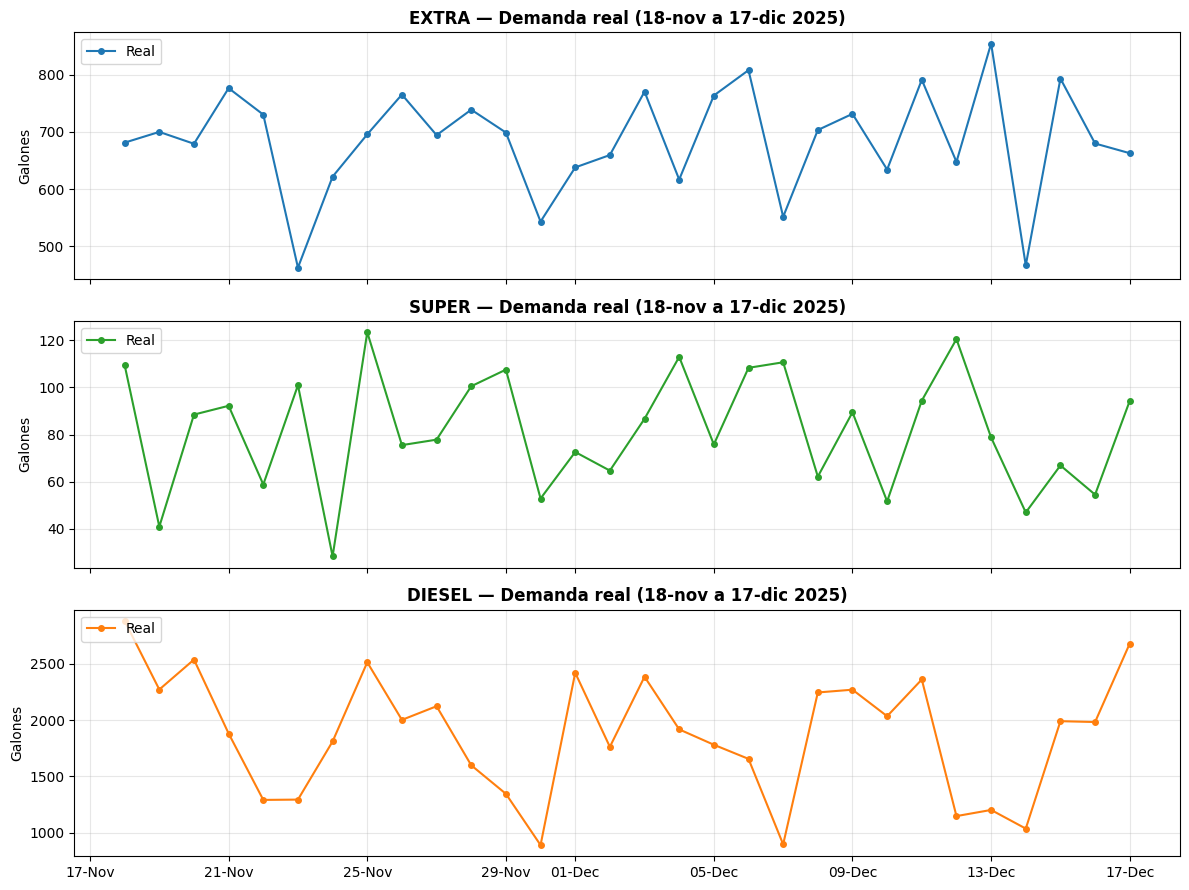

Guardado: eda_periodo_validacion.png


In [11]:
# Visualización del período de validación
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
for ax, p in zip(axes, PRODUCTOS):
    ax.plot(val_real.index, val_real[p], marker='o', ms=4,
            color=COLORES[p], label='Real')
    ax.set_title(f'{p.upper()} — Demanda real (18-nov a 17-dic 2025)', fontweight='bold')
    ax.set_ylabel('Galones'); ax.legend(loc='upper left'); ax.grid(alpha=.3)
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
plt.tight_layout(); plt.savefig('eda_periodo_validacion.png', dpi=120, bbox_inches='tight')
plt.show()
print('Guardado: eda_periodo_validacion.png')

## 5. Validación: predicho vs real

Se comparan las predicciones del modelo BiLSTM (`predicciones_diarias_30_dias.csv`) contra la demanda real del mismo período. Se reportan:
- **Error total del período** (%): sesgo agregado del pronóstico.
- **MAE diario**: error absoluto medio día a día.
- **sMAPE**: error porcentual simétrico.

In [12]:
pred = pd.read_csv(RUTA_PRED); pred['fecha'] = pd.to_datetime(pred['fecha'])
pred = pred.set_index('fecha')

comun = pred.index.intersection(val_real.index)
print(f'Días comparables: {len(comun)}')

def smape(y, yhat):
    return np.mean(2*np.abs(yhat-y)/(np.abs(y)+np.abs(yhat)+1e-9))*100

filas = []
for p in PRODUCTOS:
    yhat = pred.loc[comun, f'{p}_pred'].values
    y    = val_real.loc[comun, p].values
    filas.append({
        'producto': p,
        'pred_total':  yhat.sum(),
        'real_total':  y.sum(),
        'error_total_%': (yhat.sum()-y.sum())/y.sum()*100,
        'MAE_diario':  np.mean(np.abs(yhat-y)),
        'sMAPE_%':     smape(y, yhat),
    })
val_df = pd.DataFrame(filas).round(2)
print('\n=== VALIDACIÓN OUT-OF-SAMPLE (18-nov a 17-dic 2025) ===')
print(val_df.to_string(index=False))

Días comparables: 30

=== VALIDACIÓN OUT-OF-SAMPLE (18-nov a 17-dic 2025) ===
producto  pred_total  real_total  error_total_%  MAE_diario  sMAPE_%
   extra    18201.64    20559.90         -11.47      105.83    16.13
   super     2004.15     2447.73         -18.12       24.05    31.38
  diesel    47194.15    56216.61         -16.05      415.80    23.98


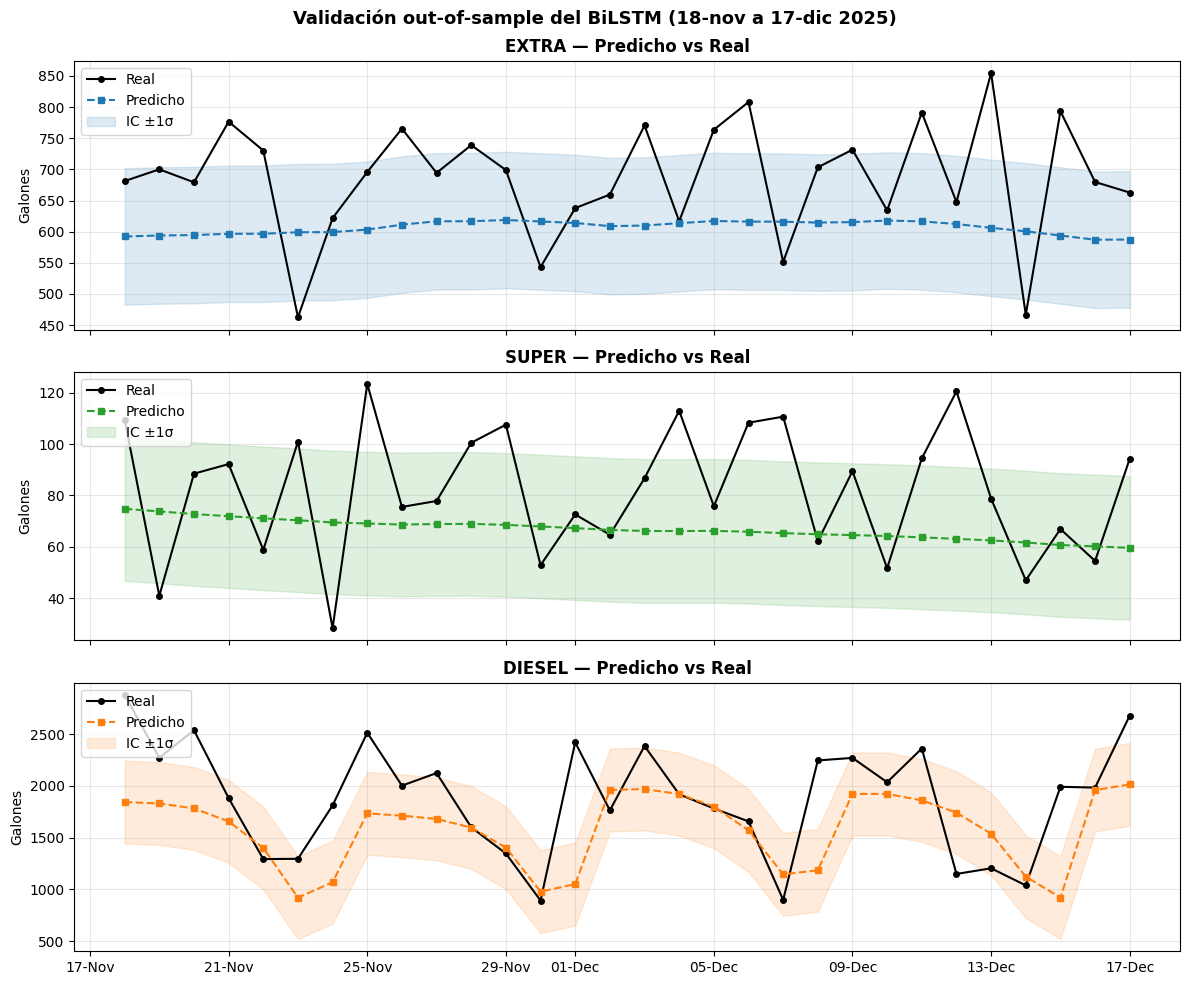

Guardado: validacion_predicho_vs_real.png


In [13]:
# Gráfico predicho vs real con banda de confianza
pred_ci = pd.read_csv(RUTA_PRED); pred_ci['fecha']=pd.to_datetime(pred_ci['fecha'])
pred_ci = pred_ci.set_index('fecha')

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
for ax, p in zip(axes, PRODUCTOS):
    ax.plot(val_real.index, val_real[p], 'k-', marker='o', ms=4, label='Real')
    ax.plot(pred_ci.index, pred_ci[f'{p}_pred'], '--', color=COLORES[p],
            marker='s', ms=4, label='Predicho')
    if f'{p}_lower' in pred_ci.columns:
        ax.fill_between(pred_ci.index, pred_ci[f'{p}_lower'], pred_ci[f'{p}_upper'],
                        color=COLORES[p], alpha=.15, label='IC ±1σ')
    ax.set_title(f'{p.upper()} — Predicho vs Real', fontweight='bold')
    ax.set_ylabel('Galones'); ax.legend(loc='upper left'); ax.grid(alpha=.3)
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
plt.suptitle('Validación out-of-sample del BiLSTM (18-nov a 17-dic 2025)',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig('validacion_predicho_vs_real.png', dpi=120, bbox_inches='tight')
plt.show()
print('Guardado: validacion_predicho_vs_real.png')

## 6. Exportación de resultados

In [14]:
val_df.to_csv('validacion_resultados.csv', index=False)
val_real.to_csv('demanda_real_validacion.csv')
print('Exportados:')
print('  - validacion_resultados.csv      (tabla de errores por producto)')
print('  - demanda_real_validacion.csv    (demanda real diaria del período)')
print('  - eda_periodo_validacion.png')
print('  - validacion_predicho_vs_real.png')

Exportados:
  - validacion_resultados.csv      (tabla de errores por producto)
  - demanda_real_validacion.csv    (demanda real diaria del período)
  - eda_periodo_validacion.png
  - validacion_predicho_vs_real.png


## 7. Lectura de resultados

> Completar tras la ejecución. Puntos a discutir:
> - **Dirección del error:** ¿el modelo subestima o sobreestima? (signo de `error_total_%`).
> - **Relación con el test:** el error out-of-sample suele ser algo mayor que el de test; si el orden de magnitud se mantiene, la evaluación en test era representativa.
> - **Estacionalidad:** si el período de validación muestra mayor demanda que los meses previos (sección 4), la subestimación puede atribuirse al pico de fin de año no plenamente capturado por el modelo.
> - **Coherencia por producto:** ¿el diésel sigue siendo el de mejor ajuste relativo, como en el test?